Ce projet est en réalité un système intelligent d’aide à la décision agricole basé sur le Machine Learning.

L’idée est de construire une application capable :

de dire quelle culture planter

puis d’estimer combien cette culture peut produire

MODULE 1 — Crop Recommendation : Classification : Quelle culture est la meilleure pour ces conditions ?

MODULE 2 — Yield Prediction : Régression : Combien cette culture va produire ?

In [87]:
import pandas as pd

df = pd.read_csv("Crop_recommendation.csv")
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


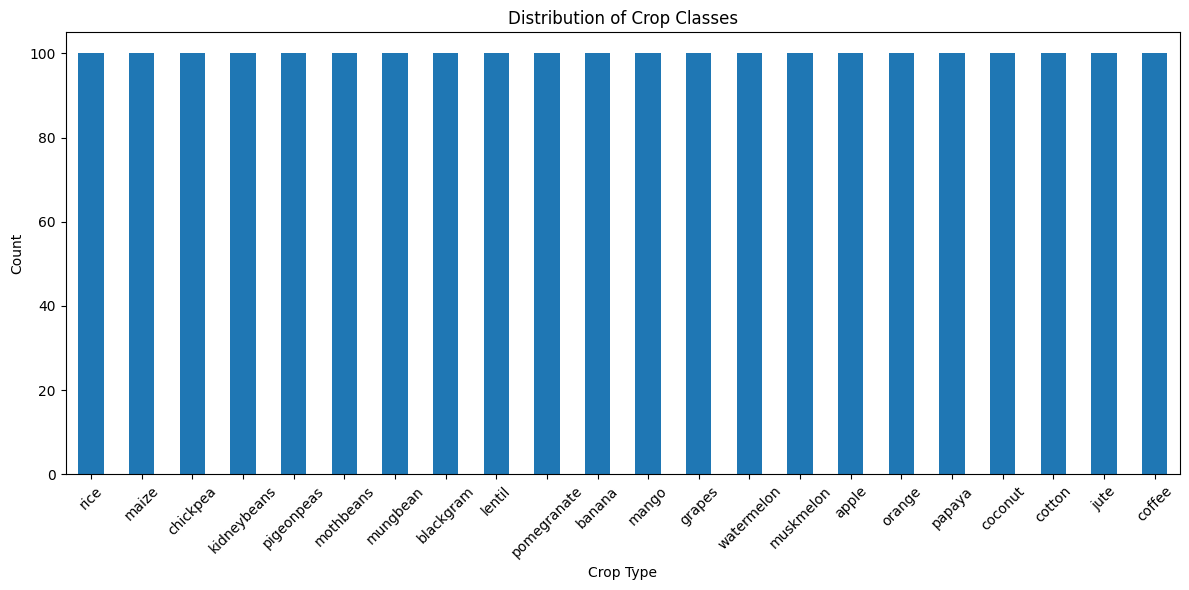

In [ ]:
import matplotlib.pyplot as plt

# Count classes
class_counts = df["label"].value_counts() 

# Plot
plt.figure(figsize=(12,6))
class_counts.plot(kind="bar")

plt.title("Distribution of Crop Classes")
plt.xlabel("Crop Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

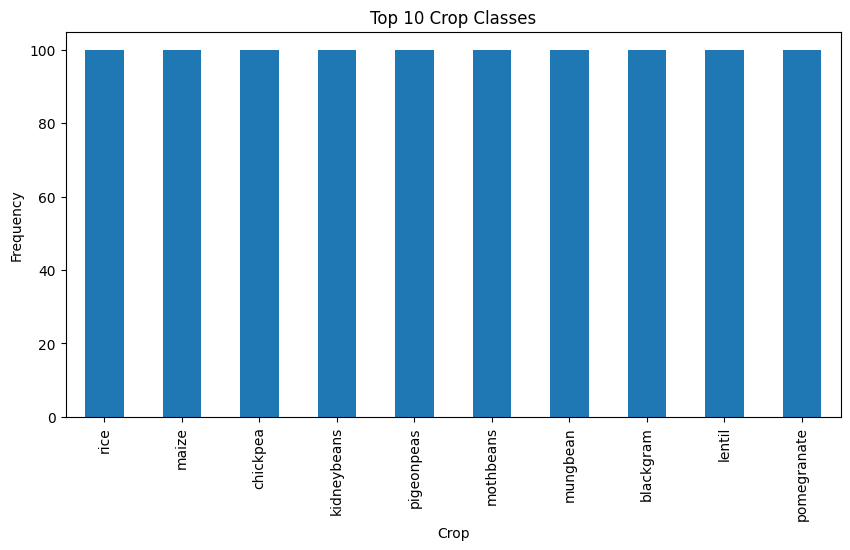

In [89]:
plt.figure(figsize=(10,5))

df["label"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Crop Classes")
plt.xlabel("Crop")
plt.ylabel("Frequency")

plt.show()

In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


| Colonne     | Représente        |
| ----------- | ----------------- |
| N           | Azote             |
| P           | Phosphore         |
| K           | Potassium         |
| temperature | Température       |
| humidity    | Humidité          |
| ph          | Acidité du sol    |
| rainfall    | Quantité de pluie |


In [34]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [5]:
numeric_df = df.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))
outliers.sum()

N                0
P              138
K              200
temperature     86
humidity        30
ph              57
rainfall       100
dtype: int64

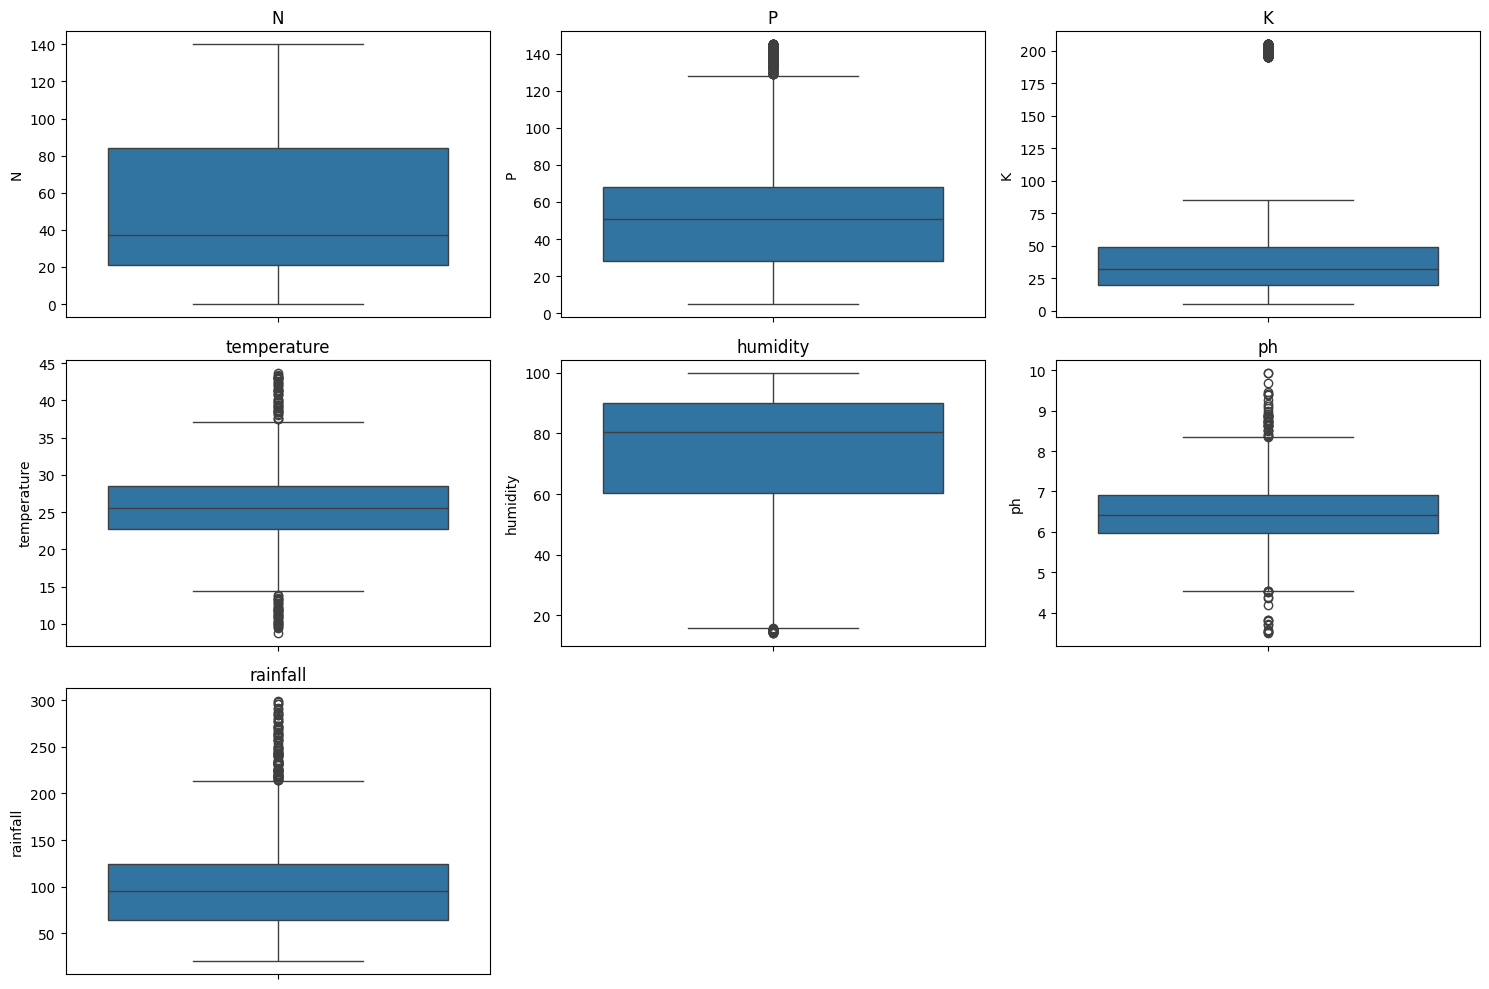

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_df = df.select_dtypes(include=['number'])

cols = numeric_df.columns
n_cols = 3  # nombre de colonnes dans la grille
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=numeric_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

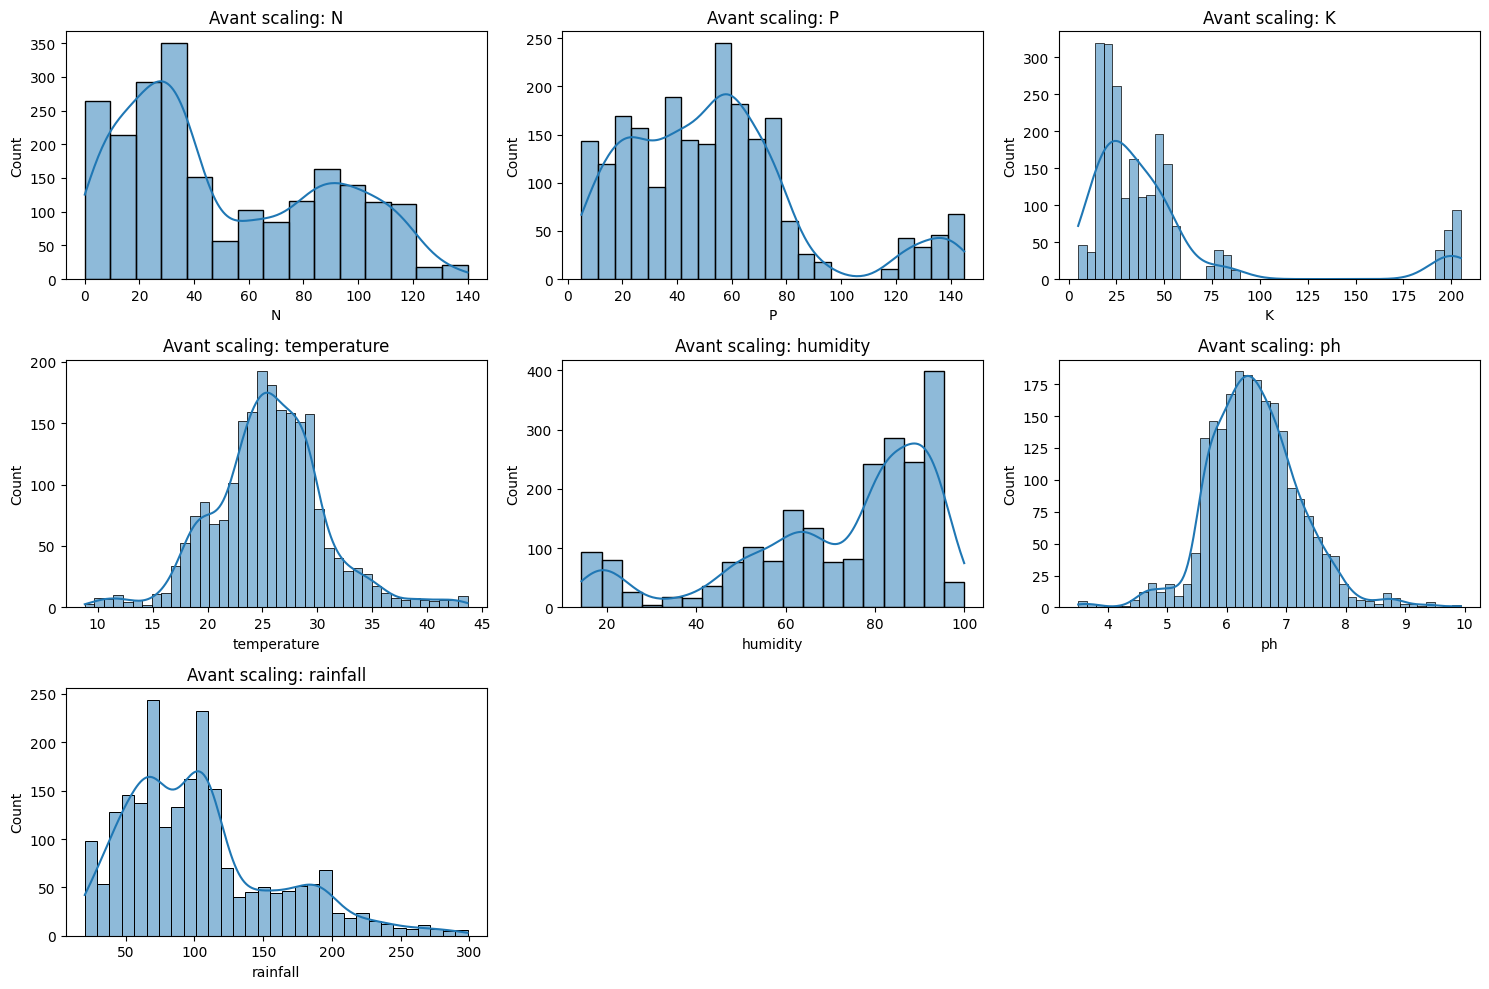

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_df = df.select_dtypes(include=['number'])

cols = numeric_df.columns
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(numeric_df[col], kde=True)
    plt.title(f"Avant scaling: {col}")

plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("=" * 50)
print("MIN AND MAX VALUES FOR EACH COLUMN")
print("=" * 50)

# Loop through each numeric column
for col in numeric_cols:
    
    # Get minimum and maximum values
    min_val = df[col].min()
    max_val = df[col].max()
    
    # Display results
    print(f"{col:15s} → Min = {min_val:.2f} | Max = {max_val:.2f}")

MIN AND MAX VALUES FOR EACH COLUMN
N               → Min = 0.00 | Max = 140.00
P               → Min = 5.00 | Max = 145.00
K               → Min = 5.00 | Max = 200.00
temperature     → Min = 8.83 | Max = 43.68
humidity        → Min = 14.26 | Max = 99.98
ph              → Min = 3.50 | Max = 9.94
rainfall        → Min = 20.21 | Max = 298.56


bounds = {
    'N':           (0, 200),
    'P':           (0, 200),
    'K':           (0, 200),
    'temperature': (0, 50),
    'humidity':    (0, 100),
    'ph':          (0, 14),
    'rainfall':    (0, 500),
}


In [41]:
# -------------------------------------------------------------
# Vérification des bornes agronomiques
# -------------------------------------------------------------
bounds = {
    'N':           (0, 200),
    'P':           (0, 200),
    'K':           (0, 200),
    'temperature': (0, 50),
    'humidity':    (0, 100),
    'ph':          (0, 14),
    'rainfall':    (0, 500),
}

print("\n Vérification des bornes agronomiques :")

for col, (lo, hi) in bounds.items():

    if col in df.columns:

        outliers_mask = (df[col] < lo) | (df[col] > hi)

        n_out = outliers_mask.sum()

        print(f"   ↳ {col:12s}: {n_out} valeur(s) hors borne")

        # Remplacement par médiane
        if n_out > 0:

            median_val = df.loc[~outliers_mask, col].median()

            df.loc[outliers_mask, col] = median_val

            print(f"Valeurs remplacées par médiane ({median_val:.2f})")


 Vérification des bornes agronomiques :
   ↳ N           : 0 valeur(s) hors borne
   ↳ P           : 0 valeur(s) hors borne
   ↳ K           : 0 valeur(s) hors borne
   ↳ temperature : 0 valeur(s) hors borne
   ↳ humidity    : 0 valeur(s) hors borne
   ↳ ph          : 0 valeur(s) hors borne
   ↳ rainfall    : 0 valeur(s) hors borne


In [42]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(numeric_df)

df_scaled = pd.DataFrame(X_scaled, columns=numeric_df.columns)
df_scaled.head()

,N,P,K,temperature,humidity,ph,rainfall
0,0.837945,-0.225,0.500000,-0.814696,0.051525,0.081874,1.809703
1,0.758893,0.175,0.423077,-0.660920,-0.005171,0.643995,2.206918
2,0.363636,0.100,0.538462,-0.447878,0.062237,1.486593,2.831689
3,0.584980,-0.400,0.384615,0.154068,-0.010603,0.583388,2.478345
4,0.648221,-0.225,0.461538,-0.944105,0.038122,1.264171,2.810808


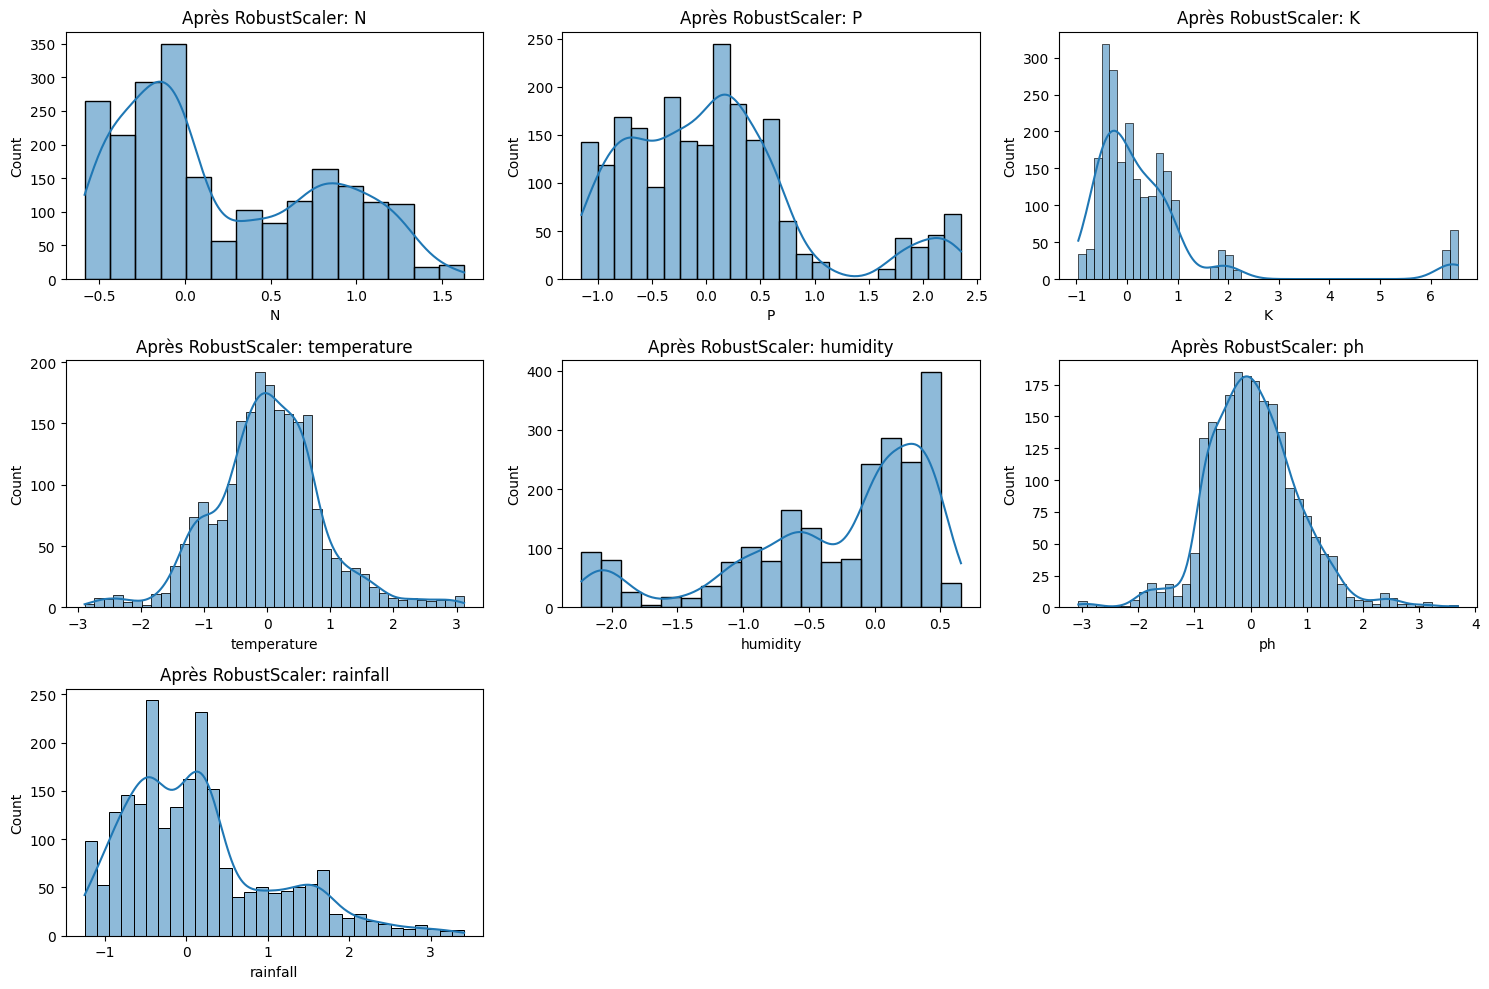

In [43]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df_scaled.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f"Après RobustScaler: {col}")

plt.tight_layout()
plt.show()

In [59]:
X = df.drop("label", axis=1)
y = df["label"]

In [60]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
import pandas as pd

importances = model.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_importance

,Feature,Importance
4,humidity,0.215018
6,rainfall,0.212344
2,K,0.185833
1,P,0.147784
0,N,0.103443
3,temperature,0.082929
5,ph,0.052649


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.9931818181818182


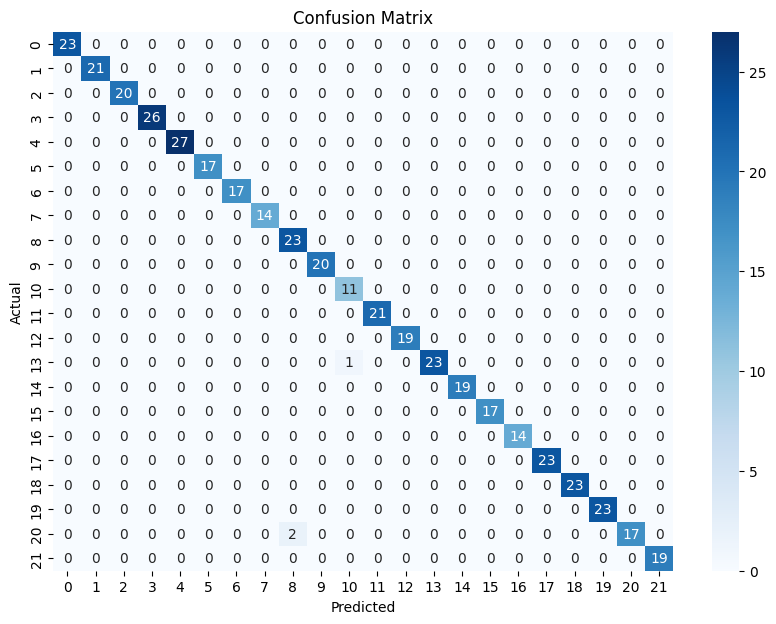

In [65]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [54]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [69]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [70]:
y_pred = xgb_model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy XGBoost:", accuracy)

Accuracy XGBoost: 0.9863636363636363


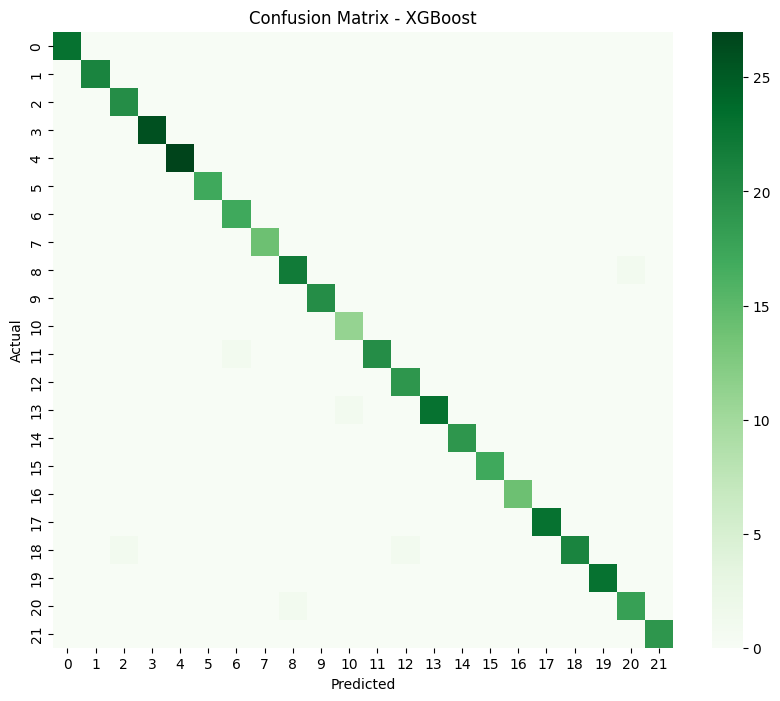

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Greens")  # annot=False si trop de classes
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.96      0.96      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

In [74]:
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# features / target
X = df.drop("label", axis=1)
y = df["label"]

# encodage target (OBLIGATOIRE pour XGBoost)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42
)

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score
import pandas as pd

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [acc_rf, acc_xgb]
})

results

,Model,Accuracy
0,Random Forest,0.993182
1,XGBoost,0.986364


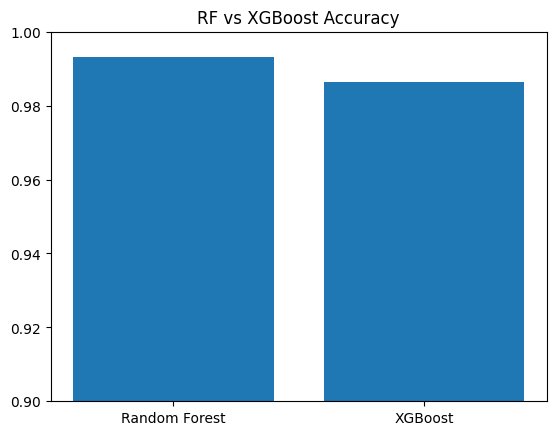

In [79]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("RF vs XGBoost Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

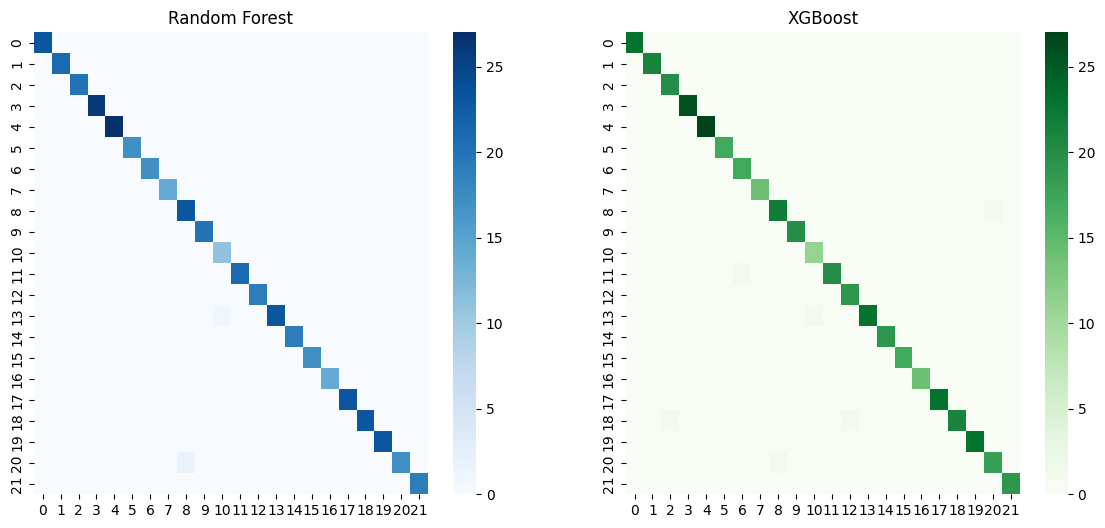

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14,6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_rf, ax=ax[0], cmap="Blues")
ax[0].set_title("Random Forest")

sns.heatmap(cm_xgb, ax=ax[1], cmap="Greens")
ax[1].set_title("XGBoost")

plt.show()

In [81]:
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

Train score: 0.0
Test score: 0.0


In [82]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

Scores: [0.99545455 0.99090909 0.99545455 0.99545455 0.98636364]
Mean: 0.9927272727272728
Std: 0.003636363636363654


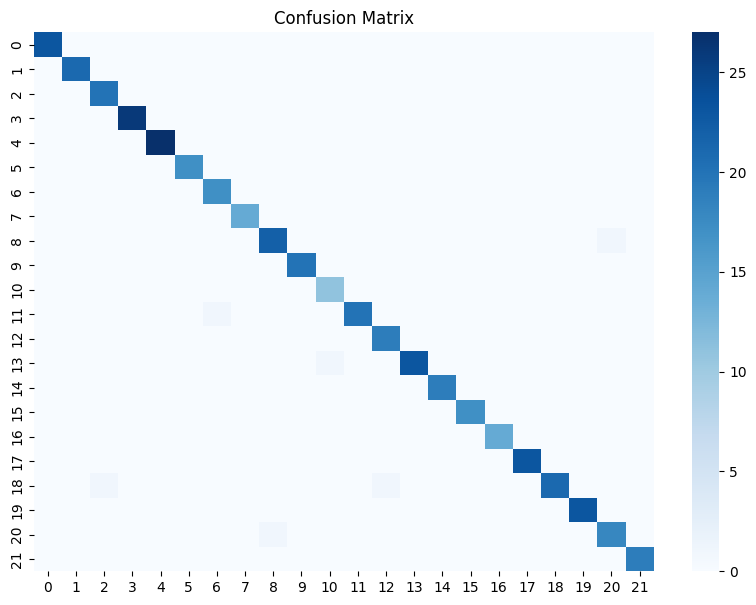

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

print(model.predict(sample))

['apple']
